<a href="https://colab.research.google.com/github/JOk3r01001/Pipeline-approach-for-fracture-classification-using-YOLO-and-Keras/blob/main/pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive


#Připojení Google Disku do prostředí Colab pro přístup k souborům
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.efficientnet import preprocess_input
from ultralytics import YOLO
from PIL import Image, ImageFile
import cv2
from sklearn.metrics import classification_report, confusion_matrix
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Cesty k datům
BASE_PATH = "/content/drive/MyDrive/BK2.0/FracAtlas2"
TEST_CSV = "/content/drive/MyDrive/YOLO_undersample/universal_test_split.csv"
YOLO_PATH = "/content/drive/MyDrive/YOLO_undersample/frac_atlas_seg_640_usample/weights/best.pt"
KERAS_PATH = "/content/drive/MyDrive/KerasNET/efficientnet_best.keras"
IMG_SIZE = (640, 640)
CONF_THRESHOLD = 0.05  # YOLO confidence

# Načtení modelů
print("Načítám modely...")
yolo_model = YOLO(YOLO_PATH)
keras_model = keras.models.load_model(KERAS_PATH)
print("Modely načteny!")

# Načtení testovacích dat
test_df = pd.read_csv(TEST_CSV)

def get_full_path(row):
    folder = 'Fractured' if row['label'] == 1 else 'Non_fractured'
    return os.path.join(BASE_PATH, 'images', folder, row['img_name'])

test_df['filepath'] = test_df.apply(get_full_path, axis=1)
print(f"Testovací snímky: {len(test_df)}")
print(f"  Zlomeniny: {test_df['label'].sum()}")
print(f"  Zdravé: {(test_df['label'] == 0).sum()}")

# Nastavení pipeline
TOP_K = 50          # kolik nejlepších boxů vyhodnotit
KERAS_TH = 0.5     # práh pro klasifikátor
PAD = 200           # padding kolem boxu 60 - 80 - 100 - 120 - 150 - 200treshold -250 - neni zlepseni +2FN -2TP

# Pipeline funce: YOLO detekce → výběr Top-K boxů → crop + padding → Keras klasifikace cropu → rozhodnutí
def run_pipeline(img_path, conf_threshold=CONF_THRESHOLD, top_k=TOP_K, keras_th=KERAS_TH, pad=PAD):
    img = cv2.imread(img_path)
    if img is None:
        return 0

    results = yolo_model(img_path, conf=conf_threshold, verbose=False)
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return 0

    confs = boxes.conf.detach().cpu().numpy()
    top_idx = np.argsort(confs)[::-1][:top_k]

    h, w = img.shape[:2]
    best_prob = 0.0

    for i in top_idx:
        box = boxes[i]
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())

        # Rozšíření boxu padding + ořez
        x1 = max(0, x1 - pad)
        y1 = max(0, y1 - pad)
        x2 = min(w, x2 + pad)
        y2 = min(h, y2 + pad)

        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        # Příprava cropu
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, IMG_SIZE)
        crop_array = np.expand_dims(crop_resized.astype(np.float32), axis=0)
        crop_preprocessed = preprocess_input(crop_array)

        # Klasifikace
        prob = float(keras_model.predict(crop_preprocessed, verbose=0)[0][0])
        best_prob = max(best_prob, prob)

        if prob > keras_th:
            return 1

    return 1 if best_prob > keras_th else 0

# Spuštění pipeline na testovací sadě
print("\nSpouštím pipeline...")
y_true = []
y_pred = []
failed = 0

for idx, row in test_df.iterrows():
    try:
        pred = run_pipeline(row['filepath'])
        y_true.append(row['label'])
        y_pred.append(pred)
    except Exception as e:
        failed += 1
        continue

    if (idx + 1) % 50 == 0:
        print(f"  Zpracováno: {idx + 1}/{len(test_df)}")

print(f"\nDokončeno! Selhalo: {failed} snímků")

# Výsledky
print("VÝSLEDKY PIPELINE")
print(classification_report(
    y_true,
    y_pred,
    target_names=['No Fracture', 'Fracture']
))

cm = confusion_matrix(y_true, y_pred)
print("Matice záměn:")
print(cm)

Načítám modely...
Modely načteny!
Testovací snímky: 409
  Zlomeniny: 72
  Zdravé: 337

Spouštím pipeline...
  Zpracováno: 50/409
WARNING ⚠️ Image Read Error /content/drive/MyDrive/BK2.0/FracAtlas2/images/Non_fractured/IMG0004076.jpg
WARNING ⚠️ Image Read Error /content/drive/MyDrive/BK2.0/FracAtlas2/images/Non_fractured/IMG0004288.jpg
WARNING ⚠️ Image Read Error /content/drive/MyDrive/BK2.0/FracAtlas2/images/Non_fractured/IMG0004079.jpg
WARNING ⚠️ Image Read Error /content/drive/MyDrive/BK2.0/FracAtlas2/images/Non_fractured/IMG0004173.jpg
  Zpracováno: 100/409
WARNING ⚠️ Image Read Error /content/drive/MyDrive/BK2.0/FracAtlas2/images/Non_fractured/IMG0004142.jpg
  Zpracováno: 150/409
WARNING ⚠️ Image Read Error /content/drive/MyDrive/BK2.0/FracAtlas2/images/Non_fractured/IMG0004155.jpg
WARNING ⚠️ Image Read Error /content/drive/MyDrive/BK2.0/FracAtlas2/images/Non_fractured/IMG0004143.jpg
  Zpracováno: 200/409
WARNING ⚠️ Image Read Error /content/drive/MyDrive/BK2.0/FracAtlas2/images/No

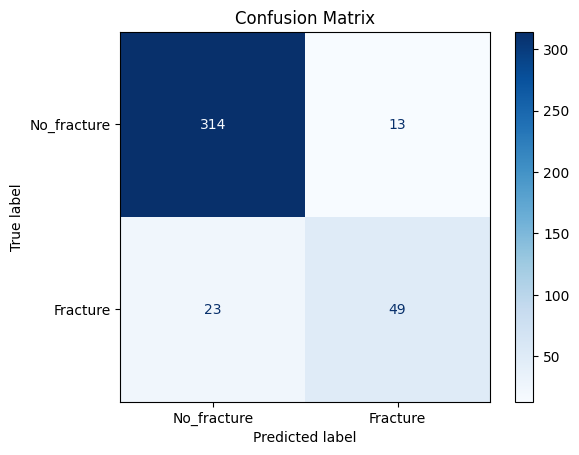

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


cm = np.array([[314, 13],
               [23, 49]])


classes = ["No_fracture", "Fracture"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(values_format='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()